# Мини-проект по написанию своего дерева и леса
На курсе мы просто учили деревья и лес используя готовые в sklearn классы. В этом ноутбуке я думаю написать свои деревья и леса для регрессии и классификации.

## 0. Импорты

In [152]:
import kagglehub
import pandas as pd
import numpy as np
import os
import matplotlib.pyplot as plt
import seaborn as sns

from sklearn.tree import DecisionTreeClassifier
from sklearn.feature_selection import VarianceThreshold
from natsort import natsorted

print('Импорты подключены успешно')

kagglehub.login() 

Импорты подключены успешно


## 1. Выбор датасета для классификации
В общем мне интересно попробовать поработать с бигдатой. Хочу взять кредитную историю на каггле от альфа-банка. Там был контест. Основной целью является написание своего решающего дерева и случайного леса, по возможности также будут использованы и реализованы другие модели. Т.к. линейную и логистическую регрессию я уже делал, то не вижу ничего страшного использовать готовые из sklearn. Также мои модели будут сравнены с деревом и лесом из sklearn. Что касается svm, есть мысль также реализовать его. В целом хочется понять как выбирать модель. Т.к. бустинг я параллельно делаю, то не уверен, что здесь он будет.

In [153]:
# Download latest version
path = kagglehub.competition_download('alfa-bank-pd-credit-history')

path = os.path.join(path, 'data_for_competition')
path_to_train_data = os.path.join(path, 'train_data')
path_to_test_data = os.path.join(path, 'test_data')
path_to_train_target = os.path.join(path, 'train_target.csv')
path_to_test_target = os.path.join(path, 'test_target.csv')

print("Path to competition files:", path)
print("Path to competition train data files:", path_to_train_data)
print("Path to competition test data files:", path_to_test_data)
print("Path to competition train target files:", path_to_train_target)
print("Path to competition test target files:", path_to_test_target)

X_train_files = [os.path.join(path_to_train_data, f) for f in os.listdir(path_to_train_data)]
X_test_files = [os.path.join(path_to_test_data, f) for f in os.listdir(path_to_test_data)]

print(f"Найдено файлов: {len(X_train_files)}")
print(f"Найдено файлов: {len(X_test_files)}")

print("Сортирую")
X_train_files = natsorted(X_train_files)
X_test_files = natsorted(X_test_files)
print("Отсортировал")

#Короче это на компе ток можно делать из-за оперативки
#dfs = []
#for file_path in X_train_files:
#    print(f"Загружаю {file_path}")
#    df = pd.read_parquet(file_path)

y_train = pd.read_csv(path_to_train_target)
y_test = pd.read_csv(path_to_test_target)

print("Данные загружены")

Path to competition files: /home/dd/.cache/kagglehub/competitions/alfa-bank-pd-credit-history/data_for_competition
Path to competition train data files: /home/dd/.cache/kagglehub/competitions/alfa-bank-pd-credit-history/data_for_competition/train_data
Path to competition test data files: /home/dd/.cache/kagglehub/competitions/alfa-bank-pd-credit-history/data_for_competition/test_data
Path to competition train target files: /home/dd/.cache/kagglehub/competitions/alfa-bank-pd-credit-history/data_for_competition/train_target.csv
Path to competition test target files: /home/dd/.cache/kagglehub/competitions/alfa-bank-pd-credit-history/data_for_competition/test_target.csv
Найдено файлов: 12
Найдено файлов: 2
Сортирую
Отсортировал
Данные загружены


## 2. EDA
Смотрим на данные просто... подгрузим один датафрейм только

In [154]:
pd.set_option('display.max_columns', None)

X_train = pd.read_parquet(X_train_files[0])

print("Размер X:", X_train.shape)
print("Размер y:", y_train.shape)
display(X_train.head(10))
display(X_train.tail())
display(y_train.head())
display(y_train.tail())

Размер X: (1974724, 61)
Размер y: (3000000, 2)


,id,rn,pre_since_opened,pre_since_confirmed,pre_pterm,pre_fterm,pre_till_pclose,pre_till_fclose,pre_loans_credit_limit,pre_loans_next_pay_summ,pre_loans_outstanding,pre_loans_total_overdue,pre_loans_max_overdue_sum,pre_loans_credit_cost_rate,pre_loans5,pre_loans530,pre_loans3060,pre_loans6090,pre_loans90,is_zero_loans5,is_zero_loans530,is_zero_loans3060,is_zero_loans6090,is_zero_loans90,pre_util,pre_over2limit,pre_maxover2limit,is_zero_util,is_zero_over2limit,is_zero_maxover2limit,enc_paym_0,enc_paym_1,enc_paym_2,enc_paym_3,enc_paym_4,enc_paym_5,enc_paym_6,enc_paym_7,enc_paym_8,enc_paym_9,enc_paym_10,enc_paym_11,enc_paym_12,enc_paym_13,enc_paym_14,enc_paym_15,enc_paym_16,enc_paym_17,enc_paym_18,enc_paym_19,enc_paym_20,enc_paym_21,enc_paym_22,enc_paym_23,enc_paym_24,enc_loans_account_holder_type,enc_loans_credit_status,enc_loans_credit_type,enc_loans_account_cur,pclose_flag,fclose_flag
0,0,1,18,9,2,3,16,10,11,3,3,0,2,11,6,16,5,4,8,1,1,1,1,1,16,2,17,1,1,1,0,0,3,3,3,3,3,3,3,3,3,4,3,3,3,3,3,3,3,3,4,3,3,3,4,1,3,4,1,0,0
1,0,2,18,9,14,14,12,12,0,3,3,0,2,11,6,16,5,4,8,1,1,1,1,1,16,2,17,1,1,1,0,0,0,0,0,0,0,0,0,0,0,1,0,0,0,0,0,0,0,0,1,0,0,0,4,1,3,4,1,0,0
2,0,3,18,9,4,8,1,11,11,0,5,0,2,8,6,16,5,4,8,1,1,1,1,1,15,2,17,0,1,1,0,0,0,0,0,0,0,0,0,0,0,1,0,0,0,0,0,0,0,0,1,0,0,0,4,1,2,3,1,1,1
3,0,4,4,1,9,12,16,7,12,2,3,0,2,4,6,16,5,4,8,0,1,1,1,1,16,2,17,1,1,1,1,0,0,0,0,0,0,0,0,0,0,1,3,3,3,3,3,3,3,3,4,3,3,3,4,1,3,1,1,0,0
4,0,5,5,12,15,2,11,12,10,2,3,0,2,4,6,16,5,4,8,1,1,1,1,1,16,2,17,1,1,1,0,0,0,0,0,0,0,3,3,3,3,4,3,3,3,3,3,3,3,3,4,3,3,3,4,1,3,4,1,0,0
5,0,6,5,0,11,8,12,11,4,2,3,0,2,4,6,16,5,4,8,1,1,1,1,1,9,5,4,0,0,0,0,0,0,0,0,0,0,0,0,0,0,1,0,0,0,0,0,0,0,3,4,3,3,3,4,1,2,3,1,0,1
6,0,7,3,9,1,2,12,14,15,5,3,0,2,3,6,16,5,4,8,1,1,1,1,1,16,2,17,1,1,1,0,0,0,0,0,0,0,0,3,3,3,4,3,3,3,3,3,3,3,3,4,3,3,3,4,1,3,4,1,0,0
7,0,8,2,9,2,3,12,14,15,5,3,0,2,13,6,16,5,4,8,1,1,1,1,1,16,2,17,1,1,1,0,0,3,3,3,3,3,3,3,3,3,4,3,3,3,3,3,3,3,3,4,3,3,3,4,1,3,4,1,0,0
8,0,9,1,9,11,13,14,8,2,5,1,0,2,11,6,16,5,4,8,1,1,1,1,1,1,2,17,0,1,1,0,0,0,0,0,0,0,0,0,0,0,1,0,0,3,3,3,3,3,3,4,3,3,3,4,1,2,4,1,0,0
9,0,10,7,9,2,10,8,8,16,4,2,0,2,11,6,16,5,4,8,1,1,1,1,1,15,2,17,0,1,1,0,0,0,0,0,0,3,3,3,3,3,4,3,3,3,3,3,3,3,3,4,3,3,3,4,1,2,4,1,0,0


,id,rn,pre_since_opened,pre_since_confirmed,pre_pterm,pre_fterm,pre_till_pclose,pre_till_fclose,pre_loans_credit_limit,pre_loans_next_pay_summ,pre_loans_outstanding,pre_loans_total_overdue,pre_loans_max_overdue_sum,pre_loans_credit_cost_rate,pre_loans5,pre_loans530,pre_loans3060,pre_loans6090,pre_loans90,is_zero_loans5,is_zero_loans530,is_zero_loans3060,is_zero_loans6090,is_zero_loans90,pre_util,pre_over2limit,pre_maxover2limit,is_zero_util,is_zero_over2limit,is_zero_maxover2limit,enc_paym_0,enc_paym_1,enc_paym_2,enc_paym_3,enc_paym_4,enc_paym_5,enc_paym_6,enc_paym_7,enc_paym_8,enc_paym_9,enc_paym_10,enc_paym_11,enc_paym_12,enc_paym_13,enc_paym_14,enc_paym_15,enc_paym_16,enc_paym_17,enc_paym_18,enc_paym_19,enc_paym_20,enc_paym_21,enc_paym_22,enc_paym_23,enc_paym_24,enc_loans_account_holder_type,enc_loans_credit_status,enc_loans_credit_type,enc_loans_account_cur,pclose_flag,fclose_flag
1974719,249998,4,1,9,14,8,10,11,8,4,2,0,2,4,6,16,5,4,8,1,1,1,1,1,11,2,17,0,1,1,0,0,0,0,0,0,0,0,0,0,0,1,0,3,3,3,3,3,3,3,4,3,3,3,4,1,2,3,1,0,1
1974720,249998,5,7,9,4,8,1,11,19,1,4,0,2,7,6,16,5,4,8,1,1,1,1,1,7,2,17,0,1,1,0,0,0,0,0,3,3,3,3,3,3,4,3,3,3,3,3,3,3,3,4,3,3,3,4,1,2,4,1,1,1
1974721,249999,1,9,0,10,8,10,11,16,2,3,0,2,7,6,16,5,4,8,1,1,1,1,1,16,2,17,1,1,1,0,0,0,0,0,0,0,0,3,3,3,4,3,3,3,3,3,3,3,3,4,3,3,3,4,1,2,3,1,0,1
1974722,249999,2,9,16,10,13,10,4,12,2,3,0,2,7,6,16,5,4,8,1,1,1,1,1,16,2,17,1,1,1,0,0,0,0,0,0,0,0,0,3,3,4,3,3,3,3,3,3,3,3,4,3,3,3,4,1,2,3,1,0,0
1974723,249999,3,9,9,6,1,0,4,16,2,4,0,2,2,6,16,5,4,8,1,1,1,1,1,5,2,17,0,1,1,0,0,0,0,0,0,0,0,0,3,3,4,3,3,3,3,3,3,3,3,4,3,3,3,4,1,2,3,1,0,0


,id,flag
0,0,0
1,1,0
2,2,0
3,3,0
4,4,0


,id,flag
2999995,2999995,0
2999996,2999996,0
2999997,2999997,0
2999998,2999998,0
2999999,2999999,0


In [155]:
display(X_train.describe())
display(X_train.info())

,id,rn,pre_since_opened,pre_since_confirmed,pre_pterm,pre_fterm,pre_till_pclose,pre_till_fclose,pre_loans_credit_limit,pre_loans_next_pay_summ,pre_loans_outstanding,pre_loans_total_overdue,pre_loans_max_overdue_sum,pre_loans_credit_cost_rate,pre_loans5,pre_loans530,pre_loans3060,pre_loans6090,pre_loans90,is_zero_loans5,is_zero_loans530,is_zero_loans3060,is_zero_loans6090,is_zero_loans90,pre_util,pre_over2limit,pre_maxover2limit,is_zero_util,is_zero_over2limit,is_zero_maxover2limit,enc_paym_0,enc_paym_1,enc_paym_2,enc_paym_3,enc_paym_4,enc_paym_5,enc_paym_6,enc_paym_7,enc_paym_8,enc_paym_9,enc_paym_10,enc_paym_11,enc_paym_12,enc_paym_13,enc_paym_14,enc_paym_15,enc_paym_16,enc_paym_17,enc_paym_18,enc_paym_19,enc_paym_20,enc_paym_21,enc_paym_22,enc_paym_23,enc_paym_24,enc_loans_account_holder_type,enc_loans_credit_status,enc_loans_credit_type,enc_loans_account_cur,pclose_flag,fclose_flag
count,1.974724e+06,1.974724e+06,1.974724e+06,1.974724e+06,1.974724e+06,1.974724e+06,1.974724e+06,1.974724e+06,1.974724e+06,1.974724e+06,1.974724e+06,1974724.0,1.974724e+06,1.974724e+06,1.974724e+06,1.974724e+06,1.974724e+06,1.974724e+06,1.974724e+06,1.974724e+06,1.974724e+06,1.974724e+06,1.974724e+06,1.974724e+06,1.974724e+06,1.974724e+06,1.974724e+06,1.974724e+06,1.974724e+06,1.974724e+06,1.974724e+06,1.974724e+06,1.974724e+06,1.974724e+06,1.974724e+06,1.974724e+06,1.974724e+06,1.974724e+06,1.974724e+06,1.974724e+06,1.974724e+06,1.974724e+06,1.974724e+06,1.974724e+06,1.974724e+06,1.974724e+06,1.974724e+06,1.974724e+06,1.974724e+06,1.974724e+06,1.974724e+06,1.974724e+06,1.974724e+06,1.974724e+06,1.974724e+06,1.974724e+06,1.974724e+06,1.974724e+06,1.974724e+06,1.974724e+06,1.974724e+06
mean,1.259465e+05,6.537471e+00,9.271325e+00,8.330264e+00,8.299071e+00,8.309444e+00,6.991781e+00,8.337011e+00,9.740888e+00,2.399848e+00,3.012951e+00,0.0,2.012115e+00,4.595422e+00,5.979092e+00,1.587038e+01,5.000825e+00,3.999941e+00,8.001086e+00,9.049189e-01,8.316909e-01,9.587416e-01,9.786112e-01,9.793075e-01,1.393471e+01,2.173915e+00,1.558773e+01,7.113070e-01,9.433263e-01,8.361092e-01,1.857206e-01,3.843271e-01,5.195359e-01,6.493839e-01,7.956054e-01,9.293010e-01,1.118293e+00,1.258795e+00,1.375658e+00,1.485436e+00,1.628490e+00,2.745407e+00,1.898640e+00,1.994735e+00,2.050834e+00,2.095171e+00,2.135815e+00,2.174022e+00,2.217775e+00,2.252719e+00,3.283859e+00,2.313242e+00,2.343014e+00,2.376717e+00,3.576724e+00,1.027562e+00,2.694898e+00,3.353936e+00,1.002386e+00,1.721385e-01,2.239336e-01
std,7.226981e+04,5.121167e+00,5.773757e+00,4.593511e+00,5.245598e+00,4.464844e+00,5.184165e+00,4.233992e+00,5.799625e+00,1.376391e+00,6.838444e-01,0.0,3.348170e-01,3.121979e+00,3.459040e-01,1.196644e+00,5.565496e-02,1.323673e-02,8.129802e-02,2.933270e-01,3.741406e-01,1.988874e-01,1.446767e-01,1.423529e-01,4.335488e+00,8.238384e-01,4.151471e+00,4.531550e-01,2.312182e-01,3.701765e-01,6.533174e-01,9.325016e-01,1.080758e+00,1.188198e+00,1.283382e+00,1.351175e+00,1.419440e+00,1.452223e+00,1.469482e+00,1.476794e+00,1.473651e+00,1.460947e+00,1.428584e+00,1.399418e+00,1.379008e+00,1.361148e+00,1.343358e+00,1.325238e+00,1.302779e+00,1.283559e+00,1.265590e+00,1.247674e+00,1.228473e+00,1.205555e+00,1.035586e+00,2.767022e-01,4.891363e-01,1.057304e+00,5.909327e-02,3.775009e-01,4.168782e-01
min,0.000000e+00,1.000000e+00,0.000000e+00,0.000000e+00,0.000000e+00,0.000000e+00,0.000000e+00,0.000000e+00,0.000000e+00,0.000000e+00,1.000000e+00,0.0,1.000000e+00,0.000000e+00,0.000000e+00,0.000000e+00,2.000000e+00,1.000000e+00,8.000000e+00,0.000000e+00,0.000000e+00,0.000000e+00,0.000000e+00,0.000000e+00,0.000000e+00,0.000000e+00,0.000000e+00,0.000000e+00,0.000000e+00,0.000000e+00,0.000000e+00,0.000000e+00,0.000000e+00,0.000000e+00,0.000000e+00,0.000000e+00,0.000000e+00,0.000000e+00,0.000000e+00,0.000000e+00,0.000000e+00,1.000000e+00,0.000000e+00,0.000000e+00,0.000000e+00,0.000000e+00,0.000000e+00,0.000000e+00,0.000000e+00,0.000000e+00,1.000000e+00,0.000000e+00,0.000000e+00,0.000000e+00,1.000000e+00,0.000000e+00,0.0000

<class 'pandas.DataFrame'>
RangeIndex: 1974724 entries, 0 to 1974723
Data columns (total 61 columns):
 #   Column                         Dtype
---  ------                         -----
 0   id                             int64
 1   rn                             int64
 2   pre_since_opened               int64
 3   pre_since_confirmed            int64
 4   pre_pterm                      int64
 5   pre_fterm                      int64
 6   pre_till_pclose                int64
 7   pre_till_fclose                int64
 8   pre_loans_credit_limit         int64
 9   pre_loans_next_pay_summ        int64
 10  pre_loans_outstanding          int64
 11  pre_loans_total_overdue        int64
 12  pre_loans_max_overdue_sum      int64
 13  pre_loans_credit_cost_rate     int64
 14  pre_loans5                     int64
 15  pre_loans530                   int64
 16  pre_loans3060                  int64
 17  pre_loans6090                  int64
 18  pre_loans90                    int64
 19  is_zero_loa

None

Все значения числовые, еще и инты, энкодинг делать не нужно.

In [156]:
display(X_train.isnull().sum())
print(f"Всего нулевых значений: {sum(X_train.isnull().sum())}")

id                         0
rn                         0
pre_since_opened           0
pre_since_confirmed        0
pre_pterm                  0
                          ..
enc_loans_credit_status    0
enc_loans_credit_type      0
enc_loans_account_cur      0
pclose_flag                0
fclose_flag                0
Length: 61, dtype: int64

Всего нулевых значений: 0


Великолепно. У нас нет нулевых значений вообще. Значит с пропусками работать не надо.  
Сейчас будет обрезка y_train, потому что мне не нужен весь файл, только первые 250000 значений. (потом уберу)

Размер y: (250000, 2)


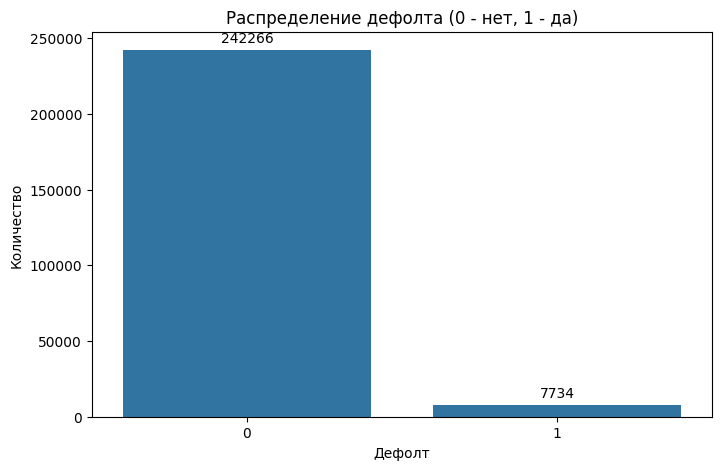

In [157]:
y_train = y_train[:250000]
print("Размер y:", y_train.shape)

plt.figure(figsize=(8, 5))
ax = sns.countplot(x='flag', data=y_train)
for container in ax.containers:
    ax.bar_label(container, padding=3)
plt.title('Распределение дефолта (0 - нет, 1 - да)')
plt.xlabel('Дефолт')
plt.ylabel('Количество')
plt.show()

## 3. Feature engineering
Сначала удалим шумные данные. В нашем случае если отклонение меньше 1%, то мы считаем это шумом.

In [174]:
print("Размер X:", X_train.shape)
print("Удаляем шумные и константные данные")

selector = VarianceThreshold(threshold=0.01)
selector.fit(X_train)
X_train_filtered = X_train[X_train.columns[selector.get_support()]]

print("Удалили")
print("Размер X:", X_train_filtered.shape)

Размер X: (1974724, 61)
Удаляем шумные и константные данные
Удалили
Размер X: (1974724, 56)


Теперь нужно создать правила агрегации для наших данных. Далее в коде они будут описаны

In [175]:
print("Формируем правила группировки")

all_columns = X_train_filtered.columns.drop('id', 'rn')
is_columns = [column for column in all_columns if (column.startswith('is_') or column.endswith('_flag'))]
enc_columns = [column for column in all_columns if column.startswith('enc_')]
other_columns = [column for column in all_columns if column not in is_columns + enc_columns]

agg_rules = {}

for col in is_columns:
    agg_rules[col] = ['mean', 'sum']
for col in enc_columns:
    agg_rules[col] = ['mean', 'max', 'last']
for col in other_columns:
    agg_rules[col] = ['mean', 'max']

print("Применяем правила")

X_train_grouped = X_train_filtered.groupby('id').agg(agg_rules)

print("Сгруппровали")

Формируем правила группировки
Применяем правила
Сгруппровали


Теперь посмотрим на наши данные собственно

In [176]:
print("Размер X:", X_train_grouped.shape)
display(X_train_grouped.head())
display(X_train_grouped.tail())

Размер X: (250000, 138)


is_zero_loans5     is_zero_loans530     is_zero_loans3060      \
             mean sum             mean sum              mean sum   
id                                                                 
0        0.900000   9         1.000000  10          1.000000  10   
1        0.857143  12         0.714286  10          0.857143  12   
2        1.000000   3         0.666667   2          0.666667   2   
3        1.000000  15         1.000000  15          1.000000  15   
4        1.000000   1         1.000000   1          1.000000   1   

   is_zero_loans6090     is_zero_loans90     is_zero_util      \
                mean sum            mean sum         mean sum   
id                                                              
0           1.000000  10        1.000000  10     0.600000   6   
1           0.857143  12        0.785714  11     0.714286  10   
2           0.666667   2        1.000000   3     0.333333   1   
3           1.000000  15        1.000000  15     0.533333   8   
4           1.000000   1        1.000000   1     1.000000   1   

   is_zero_over2limit     is_zero_maxover2limit     pclose_flag      \
                 mean sum                  mean sum        mean sum   
id                                                                    
0            0.900000   9              0.900000   9    0.100000   1   
1            0.857143  12              0.785714  11    0.071429   1   
2            1.000000   3              0.666667   2    0.666667   2   
3            0.933333  14              0.933333  14    0.333333   5   
4            1.000000   1              1.000000   1    1.000000   1   

   fclose_flag     enc_paym_0          enc_paym_1          enc_paym_2      \
          mean sum       mean max last       mean max last       mean max   
id                                                                          
0     0.200000   2   0.100000   1    0   0.000000   0    0   0.600000   3   
1     0.142857   2   0.285714   3    3   0.785714   3    3   0.714286   3   
2     0.666667   2   1.000000   3    3   1.000000   3    3   1.000000   3   
3     0.400000   6   0.000000   0    0   0.200000   3    3   0.200000   3   
4     1.000000   1   3.000000   3    3   3.000000   3    3   3.000000   3   

        enc_paym_3          enc_paym_4          enc_paym_5           \
   last       mean max last       mean max last       mean max last   
id                                                                    
0     0   0.600000   3    0   0.600000   3    0   0.600000   3    0   
1     3   0.642857   3    3   0.642857   3    3   1.285714   3    3   
2     3   1.000000   3    3   1.000000   3    3   1.000000   3    3   
3     3   0.200000   3    3   0.200000   3    3   0.200000   3    3   
4     3   3.000000   3    3   3.000000   3    3   3.000000   3    3   

   enc_paym_6          enc_paym_7          enc_paym_8          enc_paym_9      \
         mean max last       mean max last       mean max last       mean max   
id                                                                              
0    0.900000   3    3   1.200000   3    3        1.5   3    3   1.500000   3   
1    1.571429   3    3   1.642857   3    3        1.5   3    3   1.428571   3   
2    1.000000   3    3   1.000000   3    3        1.0   3    3   1.000000   3   
3    0.400000   3    3   0.400000   3    3        0.4   3    3   0.600000   3   
4    3.000000   3    3   3.000000   3    3        3.0   3    3   3.000000   3   

        enc_paym_10          enc_paym_11          enc_paym_12           \
   last        mean max last        mean max last        mean max last   
id                                                                       
0     3    1.500000   3    3    2.500000   4    4    1.800000   3    3   
1     3    1.285714   3    3    2.500000   4    4    1.714286   3    3   
2     3    2.000000   3    3    3.333333   4    4    2.333333   3    3   
3     3    1.200000   3    3    2.200000   4    4    1.200000   3    3   
4     3    3.00

is_zero_loans5     is_zero_loans530     is_zero_loans3060      \
                 mean sum             mean sum              mean sum   
id                                                                     
249995       1.000000  13         0.923077  12               1.0  13   
249996       0.826087  19         0.826087  19               1.0  23   
249997       1.000000   7         0.714286   5               1.0   7   
249998       1.000000   5         0.800000   4               1.0   5   
249999       1.000000   3         1.000000   3               1.0   3   

       is_zero_loans6090     is_zero_loans90     is_zero_util      \
                    mean sum            mean sum         mean sum   
id                                                                  
249995               1.0  13             1.0  13     0.692308   9   
249996               1.0  23             1.0  23     0.782609  18   
249997               1.0   7             1.0   7     1.000000   7   
249998               0.8   4             0.6   3     0.200000   1   
249999               1.0   3             1.0   3     0.666667   2   

       is_zero_over2limit     is_zero_maxover2limit     pclose_flag      \
                     mean sum                  mean sum        mean sum   
id                                                                        
249995           1.000000  13              0.923077  12    0.076923   1   
249996           0.869565  20              0.739130  17    0.217391   5   
249997           1.000000   7              0.857143   6    0.142857   1   
249998           0.600000   3              0.600000   3    0.400000   2   
249999           1.000000   3              1.000000   3    0.000000   0   

       fclose_flag     enc_paym_0          enc_paym_1          enc_paym_2      \
              mean sum       mean max last       mean max last       mean max   
id                                                                              
249995    0.230769   3   0.000000   0    0   0.076923   1    0   0.000000   0   
249996    0.217391   5   0.086957   1    0   0.434783   3    3   0.565217   3   
249997    0.285714   2   0.142857   1    0   0.142857   1    0   0.000000   0   
249998    0.600000   3   1.200000   3    0   0.600000   3    0   1.200000   3   
249999    0.333333   1   0.000000   0    0   0.000000   0    0   0.000000   0   

            enc_paym_3          enc_paym_4          enc_paym_5           \
       last       mean max last       mean max last       mean max last   
id                                                                        
249995    0   0.230769   3    0   0.230769   3    0   0.230769   3    0   
249996    3   0.521739   3    3   1.000000   3    3   1.086957   3    3   
249997    0   0.428571   3    0   0.428571   3    0   0.428571   3    0   
249998    0   1.200000   3    0   1.200000   3    0   1.800000   3    3   
249999    0   0.000000   0    0   0.000000   0    0   0.000000   0    0   

       enc_paym_6          enc_paym_7          enc_paym_8          enc_paym_9  \
             mean max last       mean max last       mean max last       mean   
id                                                                              
249995   0.461538   3    0   0.923077   3    3   1.153846   3    3   1.615385   
249996   1.478261   3    3   1.565217   3    3   1.565217   3    3   1.695652   
249997   0.428571   3    0   0.428571   3    0   0.428571   3    0   0.428571   
249998   1.800000   3    3   1.800000   3    3   1.800000   3    3   1.800000   
249999   0.000000   0    0   0.000000   0    0   1.000000   3    0   3.000000   

                enc_paym_10          enc_paym_11          enc_paym_12      \
       max last        mean max last        mean max last        mean max   
id                                                                          
249995   3    3    2.076923   3    3    3.307692   4    4    2.538462   3   
249996   3    3    2.130435   3    3    3.130435   4    4    2.130435

In [177]:
final_columns = [f"{col[0]}_{col[1]}" for col in X_train_grouped.columns]
X_train_final = X_train_grouped
X_train_final.columns = final_columns
display(X_train_final)
print(X_train_final.columns)

,is_zero_loans5_mean,is_zero_loans5_sum,is_zero_loans530_mean,is_zero_loans530_sum,is_zero_loans3060_mean,is_zero_loans3060_sum,is_zero_loans6090_mean,is_zero_loans6090_sum,is_zero_loans90_mean,is_zero_loans90_sum,is_zero_util_mean,is_zero_util_sum,is_zero_over2limit_mean,is_zero_over2limit_sum,is_zero_maxover2limit_mean,is_zero_maxover2limit_sum,pclose_flag_mean,pclose_flag_sum,fclose_flag_mean,fclose_flag_sum,enc_paym_0_mean,enc_paym_0_max,enc_paym_0_last,enc_paym_1_mean,enc_paym_1_max,enc_paym_1_last,enc_paym_2_mean,enc_paym_2_max,enc_paym_2_last,enc_paym_3_mean,enc_paym_3_max,enc_paym_3_last,enc_paym_4_mean,enc_paym_4_max,enc_paym_4_last,enc_paym_5_mean,enc_paym_5_max,enc_paym_5_last,enc_paym_6_mean,enc_paym_6_max,enc_paym_6_last,enc_paym_7_mean,enc_paym_7_max,enc_paym_7_last,enc_paym_8_mean,enc_paym_8_max,enc_paym_8_last,enc_paym_9_mean,enc_paym_9_max,enc_paym_9_last,enc_paym_10_mean,enc_paym_10_max,enc_paym_10_last,enc_paym_11_mean,enc_paym_11_max,enc_paym_11_last,enc_paym_12_mean,enc_paym_12_max,enc_paym_12_last,enc_paym_13_mean,enc_paym_13_max,enc_paym_13_last,enc_paym_14_mean,enc_paym_14_max,enc_paym_14_last,enc_paym_15_mean,enc_paym_15_max,enc_paym_15_last,enc_paym_16_mean,enc_paym_16_max,enc_paym_16_last,enc_paym_17_mean,enc_paym_17_max,enc_paym_17_last,enc_paym_18_mean,enc_paym_18_max,enc_paym_18_last,enc_paym_19_mean,enc_paym_19_max,enc_paym_19_last,enc_paym_20_mean,enc_paym_20_max,enc_paym_20_last,enc_paym_21_mean,enc_paym_21_max,enc_paym_21_last,enc_paym_22_mean,enc_paym_22_max,enc_paym_22_last,enc_paym_23_mean,enc_paym_23_max,enc_paym_23_last,enc_paym_24_mean,enc_paym_24_max,enc_paym_24_last,enc_loans_account_holder_type_mean,enc_loans_account_holder_type_max,enc_loans_account_holder_type_last,enc_loans_credit_status_mean,enc_loans_credit_status_max,enc_loans_credit_status_last,enc_loans_credit_type_mean,enc_loans_credit_type_max,enc_loans_credit_type_last,rn_mean,rn_max,pre_since_opened_mean,pre_since_opened_max,pre_since_confirmed_mean,pre_since_confirmed_max,pre_pterm_mean,pre_pterm_max,pre_fterm_mean,pre_fterm_max,pre_till_pclose_mean,pre_till_pclose_max,pre_till_fclose_mean,pre_till_fclose_max,pre_loans_credit_limit_mean,pre_loans_credit_limit_max,pre_loans_next_pay_summ_mean,pre_loans_next_pay_summ_max,pre_loans_outstanding_mean,pre_loans_outstanding_max,pre_loans_max_overdue_sum_mean,pre_loans_max_overdue_sum_max,pre_loans_credit_cost_rate_mean,pre_loans_credit_cost_rate_max,pre_loans5_mean,pre_loans5_max,pre_loans530_mean,pre_loans530_max,pre_util_mean,pre_util_max,pre_over2limit_mean,pre_over2limit_max,pre_maxover2limit_mean,pre_maxover2limit_max
id,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,
0,0.900000,9,1.000000,10,1.000000,10,1.000000,10,1.000000,10,0.600000,6,0.900000,9,0.900000,9,0.100000,1,0.200000,2,0.100000,1,0,0.000000,0,0,0.600000,3,0,0.600000,3,0,0.600000,3,0,0.600000,3,0,0.900000,3,3,1.200000,3,3,1.500000,3,3,1.500000,3,3,1.500000,3,3,2.500000,4,4,1.800000,3,3,1.800000,3,3,2.100000,3,3,2.100000,3,3,2.100000,3,3,2.100000,3,3,2.100000,3,3,2.400000,3,3,3.400000,4,4,2.400000,3,3,2.400000,3,3,2.400000,3,3,4.000000,4,4,1.0,1,1,2.600000,3,2,3.500000,4,4,5.5,10,8.100000,18,7.600000,12,7.100000,15,7.500000,14,11.400000,16,10.700000,14,9.600000,16,3.100000,5,2.900000,5,2.000000,2,8.000000,13,6.0,6,16.000000,16,13.600000,16,2.300000,5,15.700000,17
1,0.857143,12,0.714286,10,0.857143,12,0.857143,12,0.785714,11,0.714286,10,0.857143,12,0.785714,11,0.071429,1,0.142857,2,0.285714,3,3,0.785714,3,3,0.714286,3,3,0.642857,3,3,0.642857,3,3,1.285714,3,3,1.571429,3,3,1.642857,3,3,1.500000,3,3,1.428571,3,3,1.285714,3,3,2.500000,4,4,1.714286,3,3,1.928571,3,3,2.142857,3,3,2.214286,3,3,2.142857,3,3,2.142857,3,3,2.142857,3,3,2.142857,3,3,3.142857,4,4,2.142857,3,3,2.428571,3,3,2.357143,3,3,3.357143,4,4,1.0,1,1,2.714286,3,2,3.142857,4,3,7.5,14,11.428571,18,7.642857,14,6.642857,15,7.928571,16,10.071429,15,7.000000,15,8.142857,19,

Index(['is_zero_loans5_mean', 'is_zero_loans5_sum', 'is_zero_loans530_mean',
       'is_zero_loans530_sum', 'is_zero_loans3060_mean',
       'is_zero_loans3060_sum', 'is_zero_loans6090_mean',
       'is_zero_loans6090_sum', 'is_zero_loans90_mean', 'is_zero_loans90_sum',
       ...
       'pre_loans5_mean', 'pre_loans5_max', 'pre_loans530_mean',
       'pre_loans530_max', 'pre_util_mean', 'pre_util_max',
       'pre_over2limit_mean', 'pre_over2limit_max', 'pre_maxover2limit_mean',
       'pre_maxover2limit_max'],
      dtype='str', length=138)


## 4. Делаем просто дерево сначала
Я чет не думал, что датасет будет таким огромным, и он не совсем под обучение подходит, ну да ладно. Просто сначала сделаем простейшее дерево и посмотрим как оно справится.

In [178]:
sk_dt = DecisionTreeClassifier()